In [17]:
val Vcc = 400
val Vgrid = 130.0
val fsw = 10000.0
val fGrid = 50.0
val m = 0.8
val iL = 15.16   //Arms
val Pnom = 5910
val porcentRipple = 0.2

val deltaV = 2.0 / 3.0 * Vcc - Vgrid * sqrt(2.0)
val deltaI = porcentRipple * iL * sqrt(2.0)

val Ts = 1 / fsw
val phi = 0.0
val ta =  Ts * m * sin(PI / 3 - phi)
val tb = Ts * m * sin(phi)
val t0 = Ts - ta - tb
//val deltaT = 1 / (2 * fsw) * (1 + m/2)
val deltaT = ta / 2.0

val Linv = deltaV / deltaI * deltaT
Linv

6.690766978043292E-4

In [8]:
val Vcc = 400.0
val Vgrid = 130.0
val fsw = 10000.0
val fGrid = 50.0
val Tsw = 1.0 / fsw;
val m = 0.8
val iL = 15.16   //Arms
val Pnom = 5910.0
val porcentRipple = 0.2

val deltaI = porcentRipple * iL * sqrt(2.0)
val phi = PI / 2
val normalizedDeltaI4 = abs(
    + 2.0/3.0 * sin(phi + 2.0/3.0 * PI)
    - 1.0/6.0 * sin(phi)
    - m/2.0 * sin(phi) * sin(phi + 2.0/3.0 * PI)
)

val Linv = m * Vcc * Tsw * normalizedDeltaI4 / (2.0 * deltaI)
Linv

0.0011194302604536366

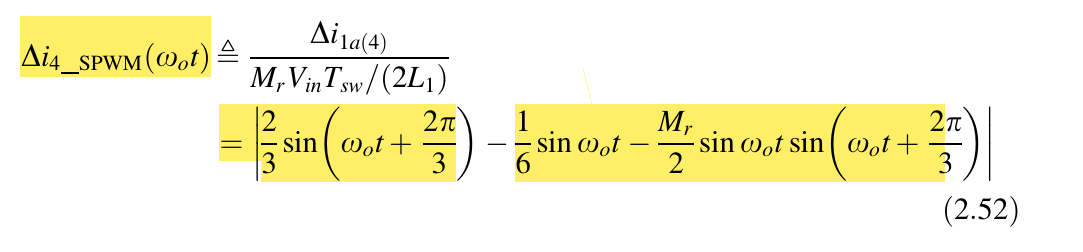

In [18]:
val Qmax = Pnom * 0.05 / 3
val Cf = Qmax / (2 * PI * fGrid * Vgrid.pow(2.0))
Cf

1.855238094029786E-5

In [19]:
val r = abs((1 / 0.05 - 1) / (Linv * Cf * (2 * PI * fsw).pow(2.0)))
r

0.38772009122418055

In [20]:
val Lgrid = r * Linv
Lgrid

2.59414478308668E-4

In [21]:
val Fres = 1 / (2 * PI) * 1 / (sqrt(Cf * (Lgrid * Linv) / (Lgrid + Linv)))
Fres

2702.552488632085

In [22]:
val Rd = 1 / (6 * PI * Fres * Cf)
Rd

1.058096033179833

In [23]:
import kotlin.math.PI

//val Lgrid = 22e-6;
//val Zg = 2 * PI * fsw * Lgrid
//val Zc = 1/(2 * PI * fsw * Cf)
//val rAtt = (1/Zg) / (1/Zg + 1/Zc) * 100
val I = 1 / abs(1 + r * Linv * Cf * (2*PI*fsw).pow(2))
I

0.05000000000000001